In [16]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = X.to_numpy()
y = y.to_numpy()

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = RandomForestRegressor(n_estimators=100, min_samples_leaf=9, max_depth=8, random_state=42)
    model.fit(X_train, y_train)

    y_hat = model.predict(X_test)

    print(f'R2 score: {r2_score(y_test, y_hat)}')


KeyboardInterrupt: 

In [2]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split


df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

model = RandomForestRegressor(n_estimators=100, min_samples_leaf=9, max_depth=8, random_state=42)
model.fit(x_train, y_train)

y_hat = model.predict(x_test)

print(f'R2 score: {r2_score(y_test, y_hat)}')

claims_df = pd.DataFrame(data={'claims_true': y_test, 'claims_predicted': y_hat})
claims_df.to_csv('RF_predictions.csv')

R2 score: 0.03837845157964104


In [3]:
dataframe = pd.read_csv('RF_predictions.csv')
dataframe

,Unnamed: 0,claims_true,claims_predicted
0,388582,0,0.025197
1,147210,0,0.012610
2,310703,0,0.063506
3,450637,1,0.068741
4,495721,0,0.102856
...,...,...,...
135598,487660,0,0.040631
135599,120812,0,0.038546
135600,241137,0,0.055997
135601,461350,1,0.074633


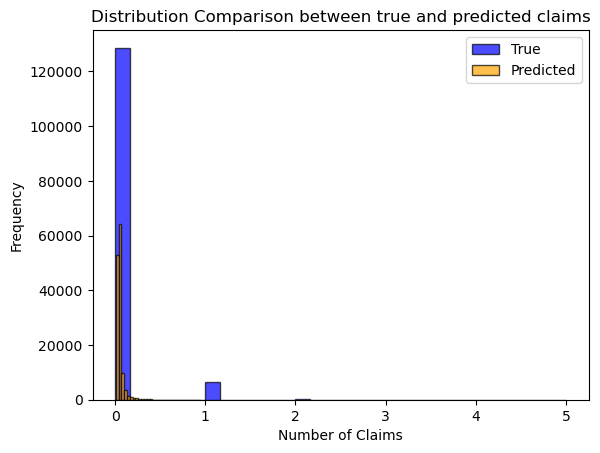

In [23]:
import matplotlib.pyplot as plt
import numpy as np

y_true = dataframe['claims_true']
y_pred = dataframe['claims_predicted']

plt.hist(y_true, bins=30, alpha=0.7, label='True', color='blue', edgecolor='black')
plt.hist(y_pred, bins=30, alpha=0.7, label='Predicted', color='orange', edgecolor='black')
plt.xlabel('Number of Claims')
plt.ylabel('Frequency')
plt.title('Distribution Comparison between true and predicted claims')
plt.legend()

Check the same configurations of hyperparameters as we used for M1 decision tree for overfitting.

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('feature_engineered.csv')

# --------------------------
# Features / Target
# --------------------------
X = df[['Density', 'DrivAge', 'Exposure', 'VehAge', 'VehPower',
        'BonusMalus', 'VehGas', 'exposure*bonusmalus',
        'Density_over_VehAge', 'VehBrand']]

X = pd.get_dummies(X, drop_first=True)
y = df['ClaimNb']

# --------------------------
# Train / Validation only
# --------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# --------------------------
# Train model
# --------------------------
clf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_leaf=9, max_depth=8)
clf.fit(X_train, y_train)

# --------------------------
# Evaluate
# --------------------------
y_pred_train = clf.predict(X_train)
y_pred_val = clf.predict(X_val)

print("--------------- TRAIN SET ---------------")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print(f"R² Score: {r2_score(y_train, y_pred_train):.4f}")

print("\n--------------- VALIDATION SET ---------------")
print("MSE:", mean_squared_error(y_val, y_pred_val))
print(f"R² Score: {r2_score(y_val, y_pred_val):.4f}")


--------------- TRAIN SET ---------------
MSE: 0.05410206782522495
R² Score: 0.0480

--------------- VALIDATION SET ---------------
MSE: 0.055380902419601974
R² Score: 0.0384


In [4]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']
numeric_cols = [
    'Density', 'DrivAge', 'Exposure', 'VehAge',
    'VehPower', 'BonusMalus',
    'exposure*bonusmalus', 'Density_over_VehAge'
]

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [12]:
import numpy as np
print(np.unique(z))

[0 1]


In [26]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeNormal
from sklearn.preprocessing import StandardScaler


In [5]:
df = pd.read_csv('feature_engineered.csv')

X = df[['Density', 'DrivAge', 'Exposure', 'VehAge','VehPower', 'BonusMalus', 'VehGas', 'exposure*bonusmalus', 'Density_over_VehAge', 'VehBrand']]
X = pd.get_dummies(X, drop_first=True, dtype=int)
y = df['ClaimNb']
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y_binned)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



In [37]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



# Build a deep and wide model with dropout
model = Sequential([
    Dense(256, activation='relu', input_shape=(X.shape[1],), kernel_initializer='he_normal'),
    Dropout(0.3),  # 30% dropout
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(1)  # output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_scaled, y,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Example predictions
predictions = model.predict(X[:5])
print(predictions)


Epoch 1/200


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27121/27121 ━━━━━━━━━━━━━━━━━━━━ 17s 595us/step - loss: 0.0620 - mae: 0.1048 - val_loss: 0.0576 - val_mae: 0.1005
Epoch 2/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 15s 571us/step - loss: 0.0569 - mae: 0.1004 - val_loss: 0.0576 - val_mae: 0.1032
Epoch 3/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 16s 577us/step - loss: 0.0569 - mae: 0.1004 - val_loss: 0.0577 - val_mae: 0.0925
Epoch 4/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 16s 598us/step - loss: 0.0569 - mae: 0.1003 - val_loss: 0.0576 - val_mae: 0.1049
Epoch 5/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 16s 599us/step - loss: 0.0569 - mae: 0.1004 - val_loss: 0.0576 - val_mae: 0.1058
Epoch 6/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 17s 632us/step - loss: 0.0569 - mae: 0.1004 - val_loss: 0.0576 - val_mae: 0.1009
Epoch 7/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 16s 592us/step - loss: 0.0569 - mae: 0.1004 - val_loss: 0.0576 - val_mae: 0.1054
Epoch 8/200
27121/27121 ━━━━━━━━━━━━━━━━━━━━ 16s 606us/step - loss: 0.0569 - mae: 0.1004 - val_loss: 0.0576 - val_mae: 0.1015
Epoc

poisson regression

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

print(sm.__version__)

0.14.6


In [6]:
exposure = X['Exposure']
X_features = X.drop(columns=['Exposure'])
scaler = StandardScaler()
X_features_scaled_array = scaler.fit_transform(X_features)
X_features_scaled = pd.DataFrame(
    X_features_scaled_array, 
    columns=X_features.columns, 
    index=X_features.index
)


X_glm = sm.add_constant(X_features_scaled, prepend=False) 

# 2. Prepare the offset (the log of the exposure)
# The offset must be in log terms
log_exposure = np.log(exposure)

# Check the first few rows of the new feature matrix
print("First 5 rows of X_glm (Features for GLM):")
print(X_glm.head())

First 5 rows of X_glm (Features for GLM):
    Density   DrivAge    VehAge  VehPower  BonusMalus  exposure*bonusmalus  \
0 -0.187160 -0.672294  1.935096  0.266627    2.253198             0.475689   
1 -0.302152  2.440453  1.758443  0.266627    2.253198            -0.973964   
2  0.599128 -0.672294 -0.714696  0.266627    1.038310            -0.253530   
3 -0.449171  1.945243 -0.538043 -0.708743   -0.496285            -0.066717   
4  0.308872 -0.601550 -1.244655  0.754312   -0.624167            -0.789000   

   Density_over_VehAge  VehGas_Regular  VehBrand_B10  VehBrand_B11  \
0            -0.128985        0.979857      -0.16408     -0.143131   
1            -0.128985        0.979857      -0.16408     -0.143131   
2            -0.128984        0.979857      -0.16408     -0.143131   
3            -0.128985       -1.020557      -0.16408     -0.143131   
4             1.677338       -1.020557      -0.16408      6.986605   

   VehBrand_B12  VehBrand_B13  VehBrand_B14  VehBrand_B2  VehBrand_B

In [10]:
# 1. Create the binary target: 1 if claim > 0, 0 otherwise
from statsmodels.genmod import families
y_binary = (y > 0).astype(int) 

# 2. Fit Logistic Regression (Binomial GLM)
hurdle1_model = sm.GLM(
    endog=y_binary,
    exog=X_glm, 
    # Use your original exposure column to get log_exposure for the offset.
    # Note: For the binary part, exposure is often used in the exog, but 
    # since you've been using it as an offset, let's keep the model simple for stability.
    family=families.Binomial() 
).fit()

print("\n--- Hurdle 1: Logistic Regression (P(Claim > 0)) Summary ---")
print(hurdle1_model.summary())


--- Hurdle 1: Logistic Regression (P(Claim > 0)) Summary ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542391
Model Family:                Binomial   Df Model:                           18
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0442e+05
Date:                Tue, 16 Dec 2025   Deviance:                   2.0883e+05
Time:                        17:51:15   Pearson chi2:                 5.38e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01292
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

array([0, 1])

In [11]:
# 1. Filter data to only include positive claims
positive_claim_mask = (y > 0)
X_positive = X_glm[positive_claim_mask]
y_positive = y[positive_claim_mask]
log_exposure_positive = log_exposure[positive_claim_mask] # Re-use the log_exposure calculated earlier

# 2. Fit Negative Binomial GLM to the positive claims subset
hurdle2_model = sm.GLM(
    endog=y_positive,
    exog=X_positive,
    offset=log_exposure_positive,
    family=families.NegativeBinomial()
).fit()

print("\n--- Hurdle 2: Negative Binomial (Claim Count | Claim > 0) Summary ---")
print(hurdle2_model.summary())


--- Hurdle 2: Negative Binomial (Claim Count | Claim > 0) Summary ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:                27211
Model:                            GLM   Df Residuals:                    27192
Model Family:        NegativeBinomial   Df Model:                           18
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -40281.
Date:                Tue, 16 Dec 2025   Deviance:                       3490.9
Time:                        17:51:27   Pearson chi2:                 8.99e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.2603
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------

/opt/anaconda3/envs/ml/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


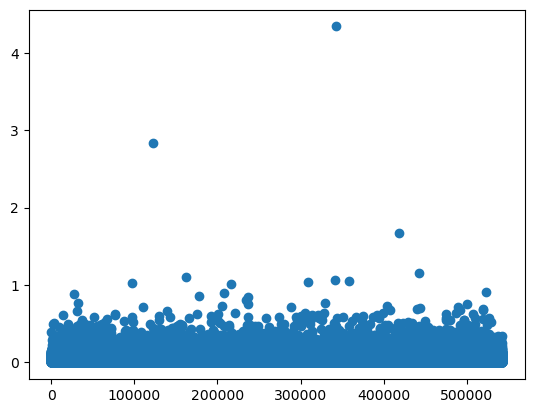

In [49]:
plt.plot(model_no_indicators.fittedvalues,'o')

In [51]:
zero_claim_count = (y == 0).sum()
total_observations = len(y)
zero_claim_percentage = (zero_claim_count / total_observations) * 100

print(f"\nPercentage of Zero Claims: {zero_claim_percentage:.2f}%")


Percentage of Zero Claims: 94.98%
